A shape = (18, 7)
A_red shape = (18, 5)

Bx TARGET = -300 mG

Optimized currents:
X1 = -4.777 A
X2 = -3.227 A
X3 = 1.180 A
Y  = -23.657 A
Z  = 71.817 A

Actual fields at 6 PMTs:

Bx:
[-299.358 -308.108 -295.15  -298.089 -294.354 -304.788]

By:
[-2.448 -3.361  7.717  0.466 -3.595  3.589]

Bz:
[ 3.742 -1.972  1.169  1.017 -5.332  1.254]

Bx TARGET = -250 mG

Optimized currents:
X1 = 6.184 A
X2 = 2.871 A
X3 = 12.391 A
Y  = -23.581 A
Z  = 71.820 A

Actual fields at 6 PMTs:

Bx:
[-250.515 -256.818 -245.93  -248.54  -242.991 -255.218]

By:
[-3.242 -3.098  7.116  0.116 -3.177  4.606]

Bz:
[ 3.729 -1.988  1.205  1.015 -5.332  1.251]

Bx TARGET = -200 mG

Optimized currents:
X1 = 17.145 A
X2 = 8.969 A
X3 = 23.602 A
Y  = -23.506 A
Z  = 71.823 A

Actual fields at 6 PMTs:

Bx:
[-201.673 -205.528 -196.71  -198.991 -191.627 -205.648]

By:
[-4.037 -2.834  6.515 -0.234 -2.758  5.624]

Bz:
[ 3.715 -2.005  1.241  1.012 -5.332  1.247]

Bx TARGET = -150 mG

Optimized currents:
X1 = 28.105 A
X2 = 15.067 A


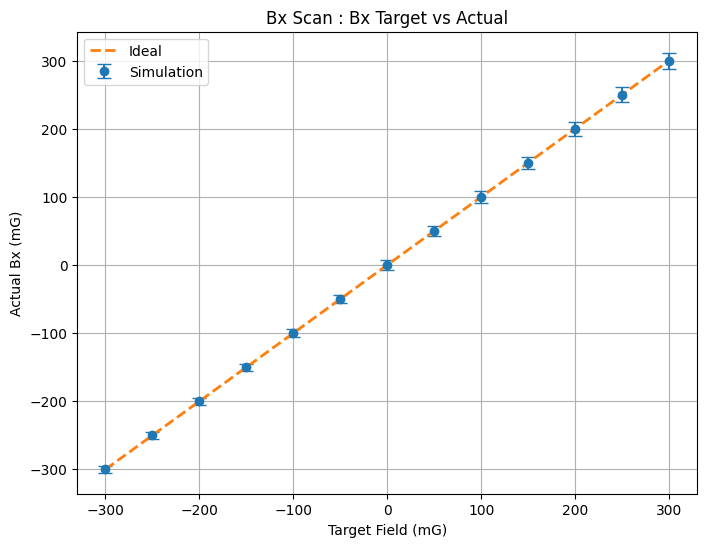

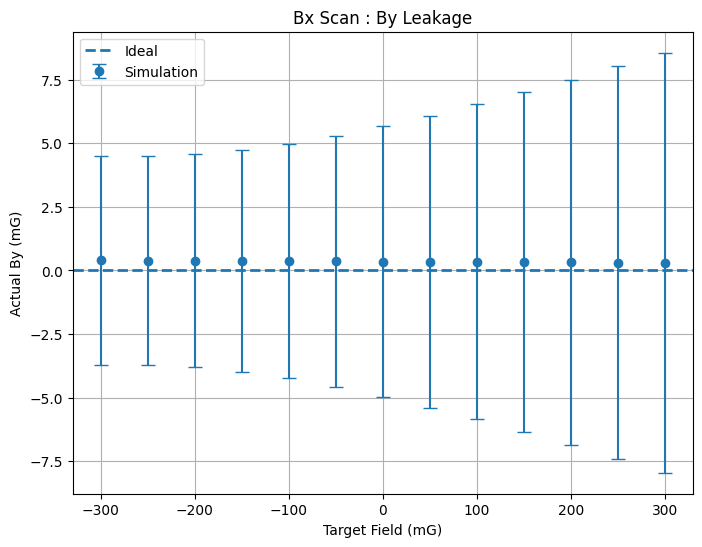

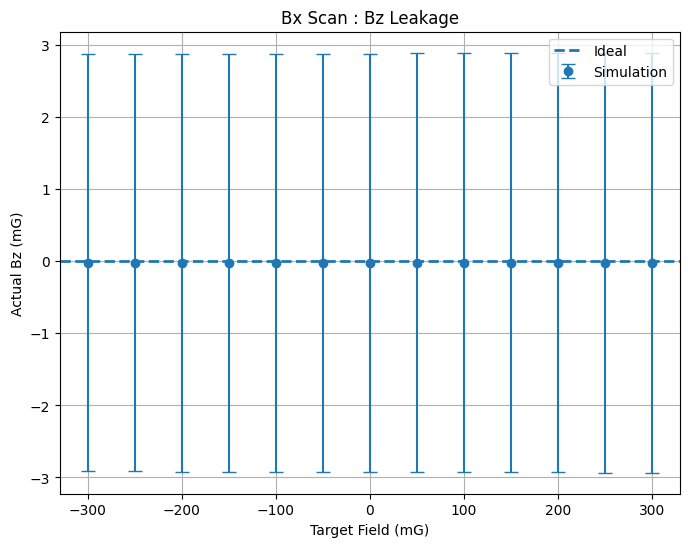

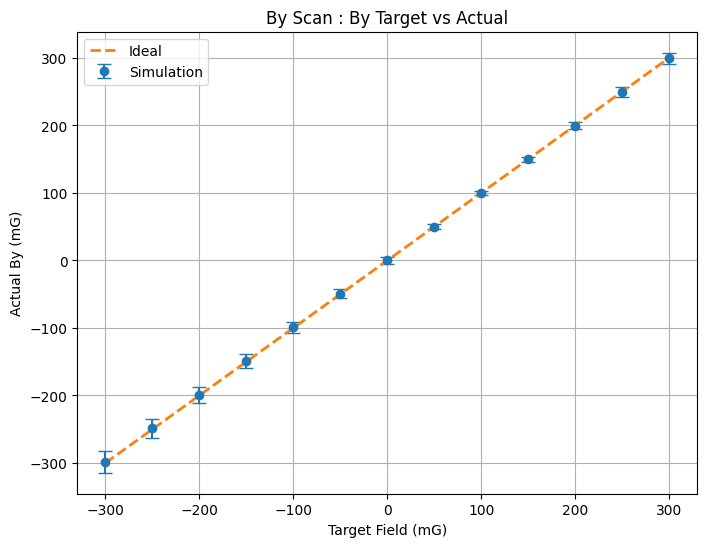

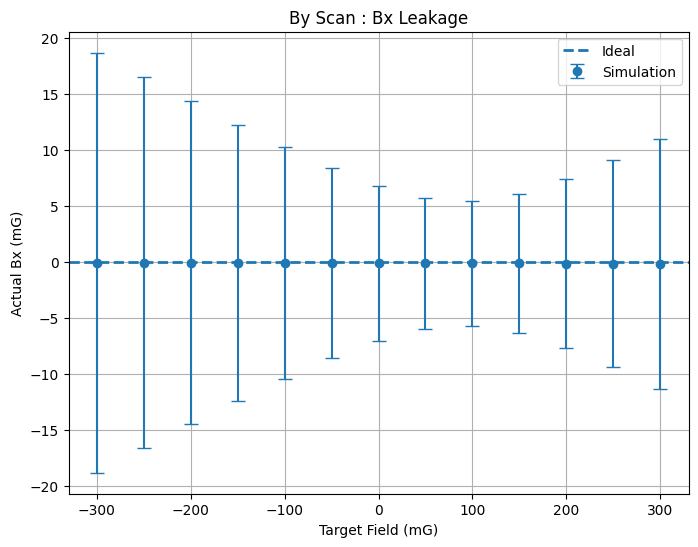

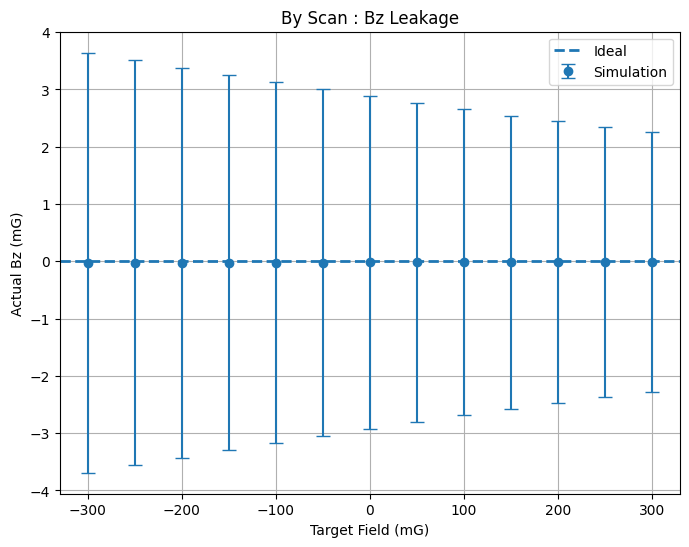

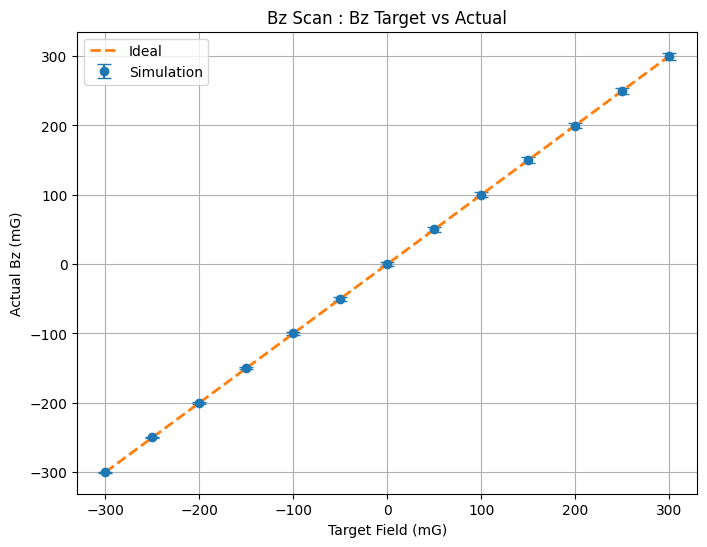

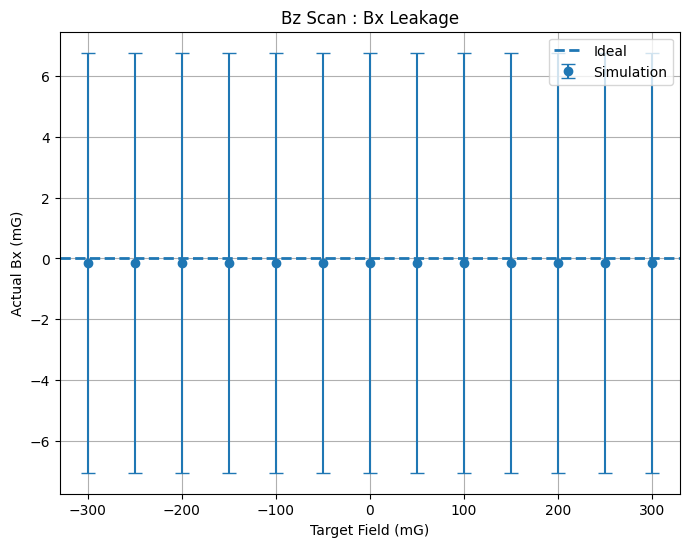

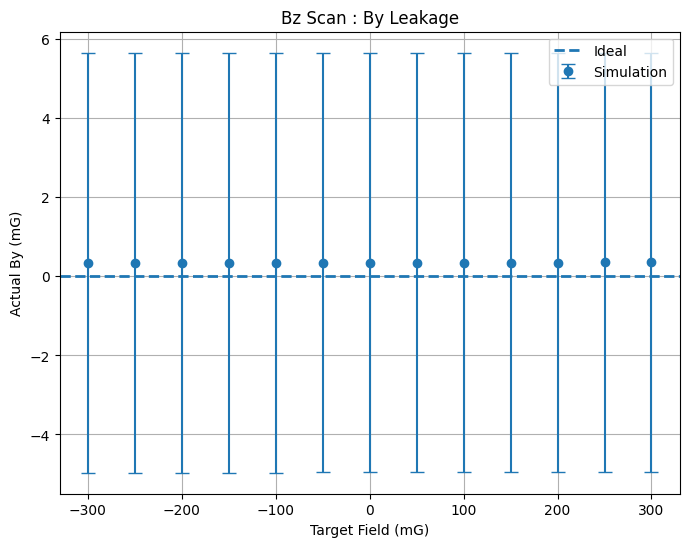

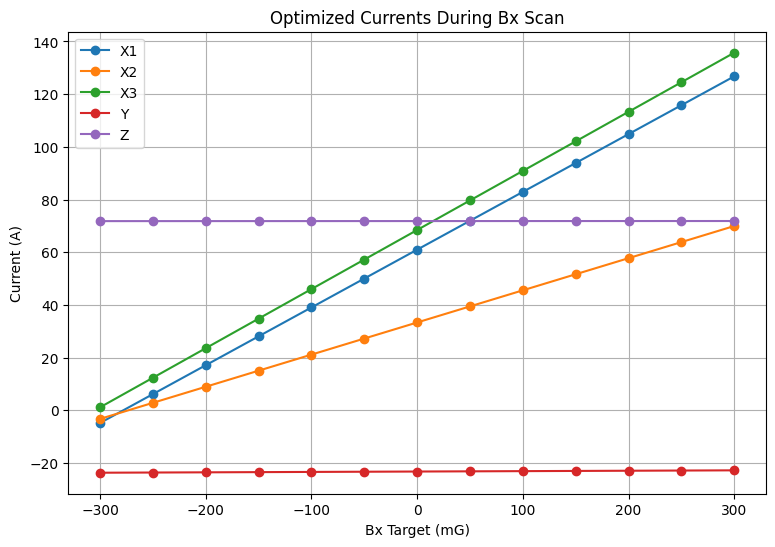

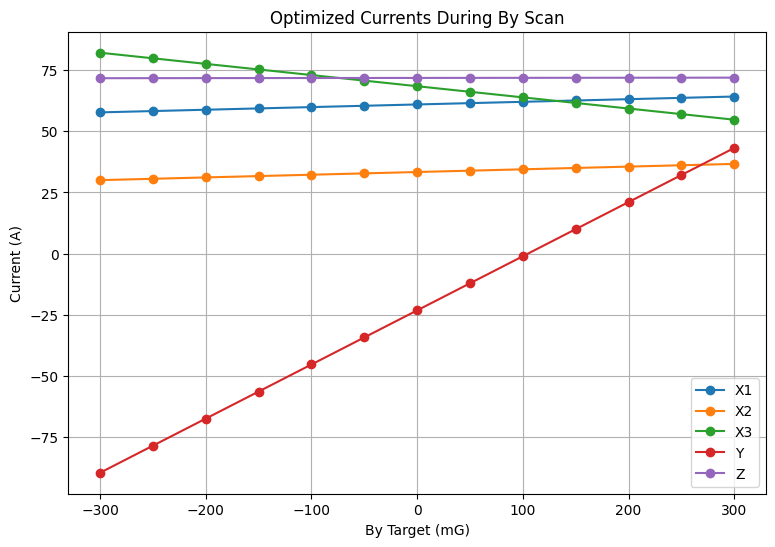

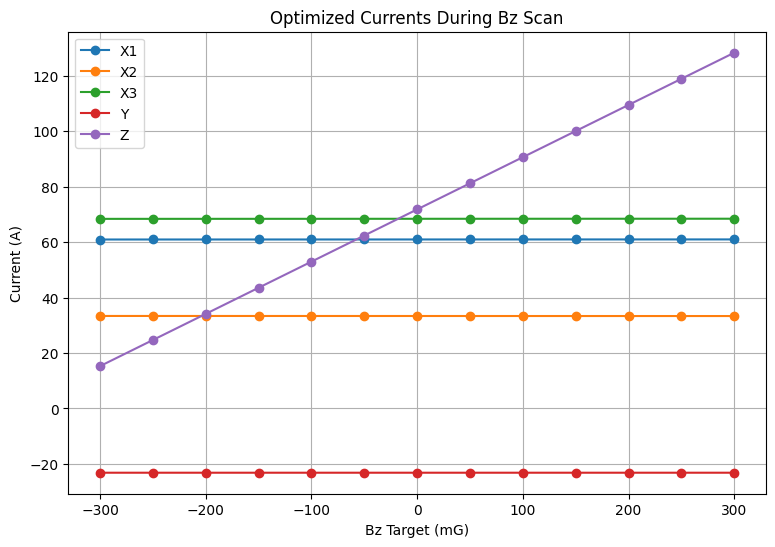

In [34]:
# ============================================================
# GLOBAL PMT SCAN ANALYSIS
#
# 6 PMT CENTERS
# USING EXISTING A MATRIX
#
# SCANS:
#   Bx : -300 → 300 mG
#   By : -300 → 300 mG
#   Bz : -300 → 300 mG
#
# PLOTS:
#   Target vs Actual
#   WITH RMS ERROR BARS
#
# ALSO:
#   Cross-component leakage plots
#
# ============================================================

import numpy as np
import matplotlib.pyplot as plt

from pathlib import Path

# ============================================================
# LOAD MATRICES
# ============================================================

project_root = Path.cwd().parent

data_dir = project_root / "data"

A = np.load(data_dir / "A.npy")

print("A shape =", A.shape)

# ============================================================
# REDUCED MATRIX
# ============================================================

A_red = np.column_stack([

    A[:,0],              # X1
    A[:,1],              # X2
    A[:,2],              # X3

    A[:,3] + A[:,4],     # Y grouped

    A[:,5] + A[:,6]      # Z grouped
])

print("A_red shape =", A_red.shape)

# ============================================================
# AMBIENT FIELD
# ============================================================

B_ambient = np.array([

    -283.38,
     106.79,
    -381.21
])

# ============================================================
# TARGET SCAN VALUES
# ============================================================

scan_values = np.arange(

    -300,
     301,
      50
)

# ============================================================
# FUNCTION:
# RUN COMPONENT SCAN
# ============================================================

def run_scan(scan_component='Bx'):

    # --------------------------------------------------------
    # STORAGE
    # --------------------------------------------------------

    actual_means_x = []
    actual_rms_x   = []

    actual_means_y = []
    actual_rms_y   = []

    actual_means_z = []
    actual_rms_z   = []

    currents_all = []

    # --------------------------------------------------------
    # LOOP OVER TARGETS
    # --------------------------------------------------------

    for target in scan_values:

        # ----------------------------------------------------
        # USER INPUT FIELD
        # ----------------------------------------------------

        if scan_component == 'Bx':

            B_in = np.array([

                target,
                0,
                0
            ])

        elif scan_component == 'By':

            B_in = np.array([

                0,
                target,
                0
            ])

        elif scan_component == 'Bz':

            B_in = np.array([

                0,
                0,
                target
            ])

        # ----------------------------------------------------
        # COIL GENERATED TARGET
        # ----------------------------------------------------

        target_single = B_in - B_ambient

        # ----------------------------------------------------
        # BUILD 18 VECTOR
        # ----------------------------------------------------

        Bx_vec = np.full(

            6,
            target_single[0]
        )

        By_vec = np.full(

            6,
            target_single[1]
        )

        Bz_vec = np.full(

            6,
            target_single[2]
        )

        B_target = np.concatenate([

            Bx_vec,
            By_vec,
            Bz_vec
        ])

        # ----------------------------------------------------
        # OPTIMIZATION
        # ----------------------------------------------------

        I_opt, residuals, rank, s = np.linalg.lstsq(

            A_red,
            B_target,
            rcond=None
        )

        currents_all.append(I_opt)

        # ----------------------------------------------------
        # COIL FIELD
        # ----------------------------------------------------

        B_coil = A_red @ I_opt

        # ----------------------------------------------------
        # AMBIENT VECTOR
        # ----------------------------------------------------

        B_ambient_vec = np.concatenate([

            np.full(6, B_ambient[0]),
            np.full(6, B_ambient[1]),
            np.full(6, B_ambient[2])
        ])

        # ----------------------------------------------------
        # TOTAL ACTUAL FIELD
        # ----------------------------------------------------

        B_actual = B_coil + B_ambient_vec

        # ----------------------------------------------------
        # EXTRACT COMPONENTS
        # ----------------------------------------------------

        Bx_actual = B_actual[:6]

        By_actual = B_actual[6:12]

        Bz_actual = B_actual[12:18]

        # ----------------------------------------------------
        # STORE STATISTICS
        # ----------------------------------------------------

        actual_means_x.append(

            np.mean(Bx_actual)
        )

        actual_rms_x.append(

            np.std(Bx_actual)
        )

        actual_means_y.append(

            np.mean(By_actual)
        )

        actual_rms_y.append(

            np.std(By_actual)
        )

        actual_means_z.append(

            np.mean(Bz_actual)
        )

        actual_rms_z.append(

            np.std(Bz_actual)
        )

        # ----------------------------------------------------
        # PRINT
        # ----------------------------------------------------

        print("\n================================================")

        print(f"{scan_component} TARGET = {target} mG")

        print("================================================")

        print("\nOptimized currents:")

        print(f"X1 = {I_opt[0]:.3f} A")
        print(f"X2 = {I_opt[1]:.3f} A")
        print(f"X3 = {I_opt[2]:.3f} A")

        print(f"Y  = {I_opt[3]:.3f} A")
        print(f"Z  = {I_opt[4]:.3f} A")

        print("\nActual fields at 6 PMTs:")

        print("\nBx:")
        print(np.round(Bx_actual,3))

        print("\nBy:")
        print(np.round(By_actual,3))

        print("\nBz:")
        print(np.round(Bz_actual,3))

    # --------------------------------------------------------
    # RETURN
    # --------------------------------------------------------

    return {

        'currents': np.array(currents_all),

        'Bx_mean': np.array(actual_means_x),
        'Bx_rms':  np.array(actual_rms_x),

        'By_mean': np.array(actual_means_y),
        'By_rms':  np.array(actual_rms_y),

        'Bz_mean': np.array(actual_means_z),
        'Bz_rms':  np.array(actual_rms_z),
    }

# ============================================================
# RUN ALL SCANS
# ============================================================

results_Bx = run_scan('Bx')

results_By = run_scan('By')

results_Bz = run_scan('Bz')

# ============================================================
# FUNCTION:
# PLOT RESPONSE
# ============================================================

def plot_response(

    targets,
    means,
    rms,

    ylabel,
    title,

    ideal='diagonal'
):

    plt.figure(figsize=(8,6))

    # --------------------------------------------------------
    # ERROR BARS
    # --------------------------------------------------------

    plt.errorbar(

        targets,
        means,

        yerr=rms,

        fmt='o',

        capsize=5,

        label='Simulation'
    )

    # --------------------------------------------------------
    # IDEAL LINE
    # --------------------------------------------------------

    if ideal == 'diagonal':

        plt.plot(

            targets,
            targets,

            '--',

            linewidth=2,

            label='Ideal'
        )

    elif ideal == 'zero':

        plt.axhline(

            y=0,

            linestyle='--',

            linewidth=2,

            label='Ideal'
        )

    # --------------------------------------------------------
    # LABELS
    # --------------------------------------------------------

    plt.xlabel('Target Field (mG)')

    plt.ylabel(ylabel)

    plt.title(title)

    plt.grid(True)

    plt.legend()

    plt.show()


# ============================================================
# Bx SCAN PLOTS
# ============================================================
plot_response(

    scan_values,

    results_Bx['Bx_mean'],
    results_Bx['Bx_rms'],

    'Actual Bx (mG)',

    'Bx Scan : Bx Target vs Actual',

    ideal='diagonal'
)

plot_response(

    scan_values,

    results_Bx['By_mean'],
    results_Bx['By_rms'],

    'Actual By (mG)',

    'Bx Scan : By Leakage',

    ideal='zero'
)

plot_response(

    scan_values,

    results_Bx['Bz_mean'],
    results_Bx['Bz_rms'],

    'Actual Bz (mG)',

    'Bx Scan : Bz Leakage',

    ideal='zero'
)
# ============================================================
# By SCAN PLOTS
# ============================================================

plot_response(

    scan_values,

    results_By['By_mean'],
    results_By['By_rms'],

    'Actual By (mG)',

    'By Scan : By Target vs Actual',

    ideal='diagonal'
)

plot_response(

    scan_values,

    results_By['Bx_mean'],
    results_By['Bx_rms'],

    'Actual Bx (mG)',

    'By Scan : Bx Leakage',

    ideal='zero'
)

plot_response(

    scan_values,

    results_By['Bz_mean'],
    results_By['Bz_rms'],

    'Actual Bz (mG)',

    'By Scan : Bz Leakage',

    ideal='zero'
)
# ============================================================
# Bz SCAN PLOTS
# ============================================================

plot_response(

    scan_values,

    results_Bz['Bz_mean'],
    results_Bz['Bz_rms'],

    'Actual Bz (mG)',

    'Bz Scan : Bz Target vs Actual',

    ideal='diagonal'
)

plot_response(

    scan_values,

    results_Bz['Bx_mean'],
    results_Bz['Bx_rms'],

    'Actual Bx (mG)',

    'Bz Scan : Bx Leakage',

    ideal='zero'
)

plot_response(

    scan_values,

    results_Bz['By_mean'],
    results_Bz['By_rms'],

    'Actual By (mG)',

    'Bz Scan : By Leakage',

    ideal='zero'
)

# ============================================================
# CURRENT EVOLUTION PLOTS
# ============================================================

coil_labels = [

    'X1',
    'X2',
    'X3',
    'Y',
    'Z'
]

# ------------------------------------------------------------
# Bx scan currents
# ------------------------------------------------------------

plt.figure(figsize=(9,6))

for i in range(5):

    plt.plot(

        scan_values,

        results_Bx['currents'][:,i],

        marker='o',

        label=coil_labels[i]
    )

plt.xlabel('Bx Target (mG)')

plt.ylabel('Current (A)')

plt.title('Optimized Currents During Bx Scan')

plt.grid(True)

plt.legend()

plt.show()

# ------------------------------------------------------------
# By scan currents
# ------------------------------------------------------------

plt.figure(figsize=(9,6))

for i in range(5):

    plt.plot(

        scan_values,

        results_By['currents'][:,i],

        marker='o',

        label=coil_labels[i]
    )

plt.xlabel('By Target (mG)')

plt.ylabel('Current (A)')

plt.title('Optimized Currents During By Scan')

plt.grid(True)

plt.legend()

plt.show()

# ------------------------------------------------------------
# Bz scan currents
# ------------------------------------------------------------

plt.figure(figsize=(9,6))

for i in range(5):

    plt.plot(

        scan_values,

        results_Bz['currents'][:,i],

        marker='o',

        label=coil_labels[i]
    )

plt.xlabel('Bz Target (mG)')

plt.ylabel('Current (A)')

plt.title('Optimized Currents During Bz Scan')

plt.grid(True)

plt.legend()

plt.show()

In [45]:
# ============================================================
# COMBINED RESPONSE PLOT
# ============================================================

def plot_combined_scan(

    scan_values,

    main_mean,
    main_rms,

    leak1_mean,
    leak1_rms,

    leak2_mean,
    leak2_rms,

    main_label,
    leak1_label,
    leak2_label,

    title
):

    plt.figure(figsize=(9,6))

    # --------------------------------------------------------
    # MAIN COMPONENT
    # --------------------------------------------------------

    plt.errorbar(

        scan_values,

        main_mean,

        yerr=main_rms,

        capsize=4,

        label=main_label
    )

    # --------------------------------------------------------
    # LEAKAGE 1
    # --------------------------------------------------------

    plt.errorbar(

        scan_values,

        leak1_mean,

        yerr=leak1_rms,

        capsize=4,

        label=leak1_label
    )

    # --------------------------------------------------------
    # LEAKAGE 2
    # --------------------------------------------------------

    plt.errorbar(

        scan_values,

        leak2_mean,

        yerr=leak2_rms,

        capsize=4,

        label=leak2_label
    )

    # --------------------------------------------------------
    # IDEAL LINES
    # --------------------------------------------------------

    # desired response

    plt.plot(

        scan_values,
        scan_values,

        '--',

        linewidth=2
    )

    # zero leakage

    plt.axhline(

        y=0,

        linestyle='--',

        linewidth=1.5
    )

    # --------------------------------------------------------
    # LABELS
    # --------------------------------------------------------

    plt.xlabel('Target Field (mG)')

    plt.ylabel('Actual Field (mG)')

    plt.title(title)

    plt.grid(True)

    plt.legend()

    plt.show()

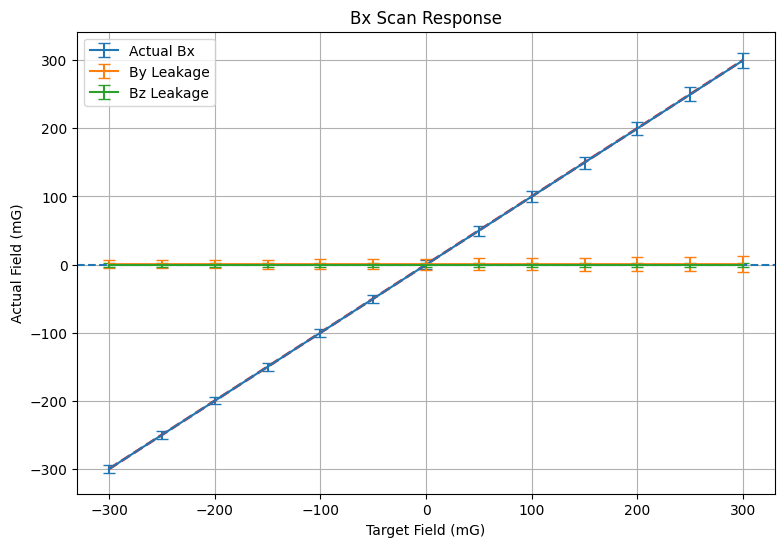

In [40]:
plot_combined_scan(

    scan_values,

    results_Bx['Bx_mean'],
    results_Bx['Bx_rms'],

    results_Bx['By_mean'],
    results_Bx['By_rms'],

    results_Bx['Bz_mean'],
    results_Bx['Bz_rms'],

    'Actual Bx',
    'By Leakage',
    'Bz Leakage',

    'Bx Scan Response'
)

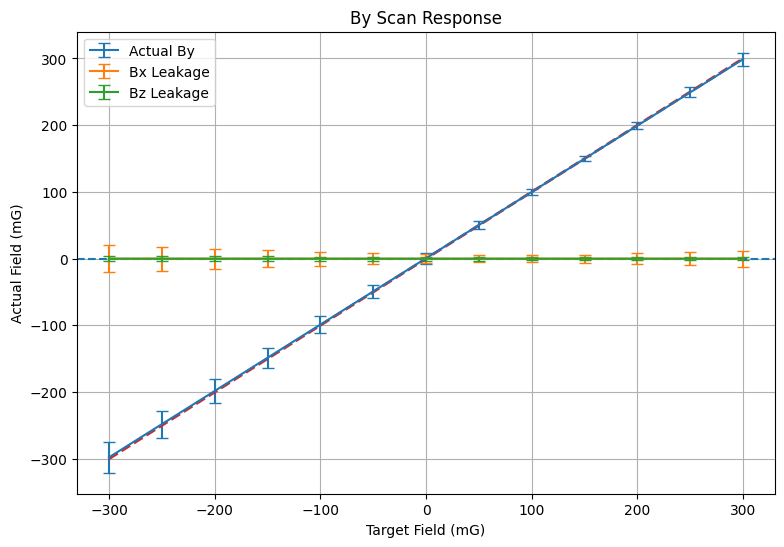

In [41]:
plot_combined_scan(

    scan_values,

    results_By['By_mean'],
    results_By['By_rms'],

    results_By['Bx_mean'],
    results_By['Bx_rms'],

    results_By['Bz_mean'],
    results_By['Bz_rms'],

    'Actual By',
    'Bx Leakage',
    'Bz Leakage',

    'By Scan Response'
)

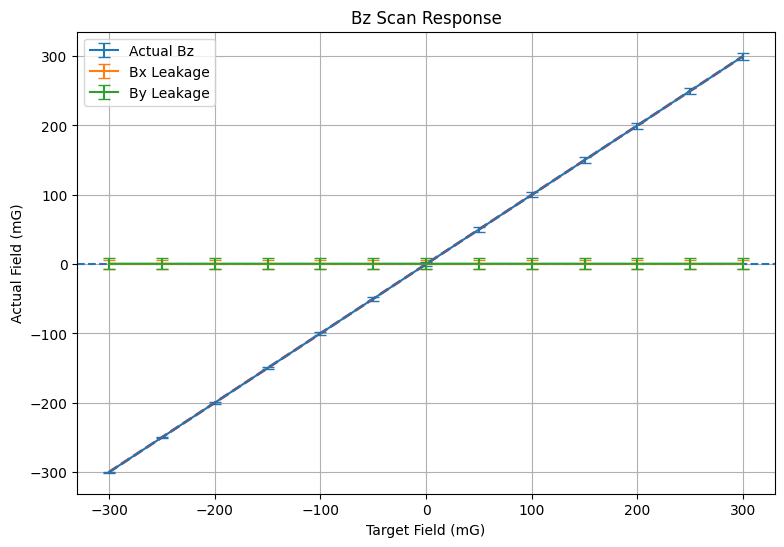

In [42]:
plot_combined_scan(

    scan_values,

    results_Bz['Bz_mean'],
    results_Bz['Bz_rms'],

    results_Bz['Bx_mean'],
    results_Bz['Bx_rms'],

    results_Bz['By_mean'],
    results_Bz['By_rms'],

    'Actual Bz',
    'Bx Leakage',
    'By Leakage',

    'Bz Scan Response'
)

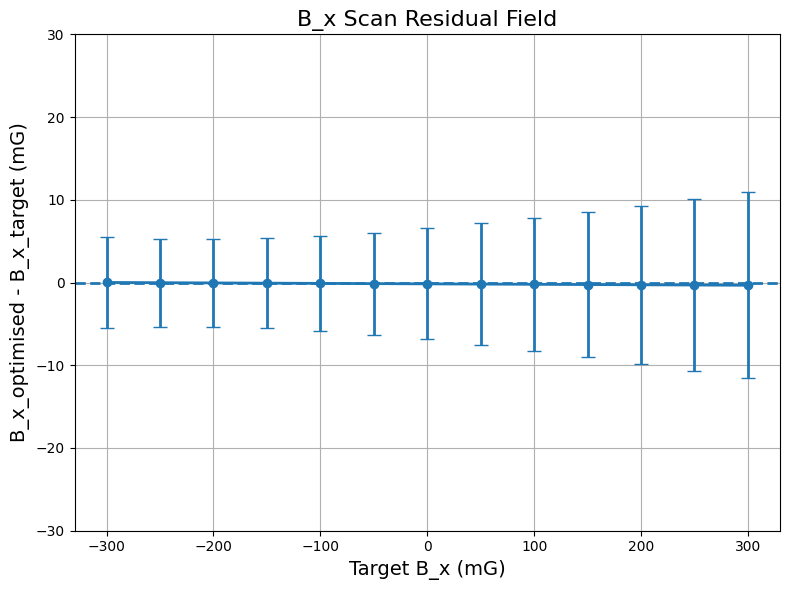

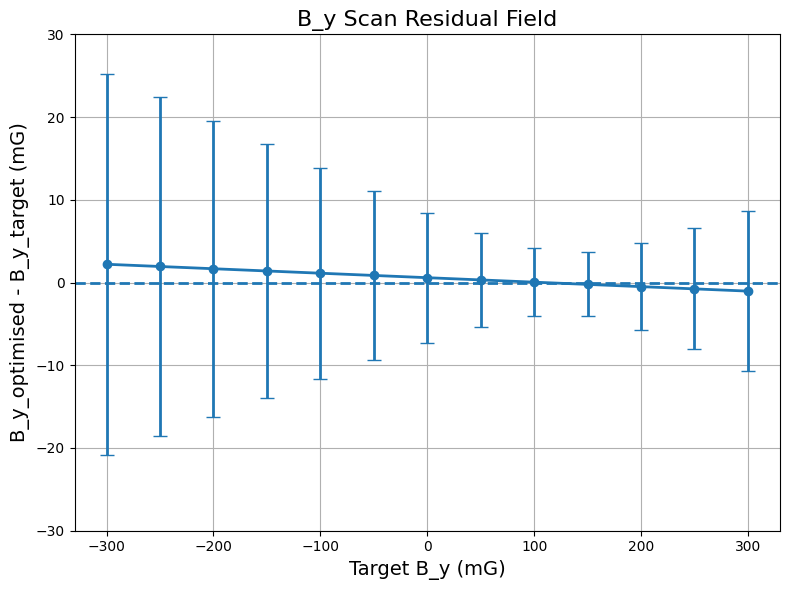

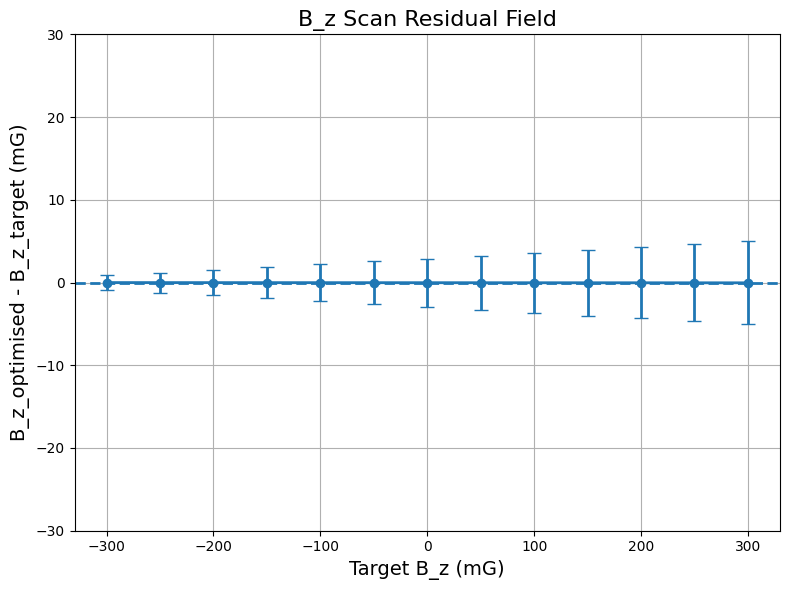

In [43]:
# ============================================================
# RESIDUAL FIELD PLOTS
#
# Plot:
#
# (B_actual - B_target)
# vs
# B_target
#
# for:
# Bx scan
# By scan
# Bz scan
#
# ============================================================

import matplotlib.pyplot as plt

# ============================================================
# GENERIC RESIDUAL PLOT FUNCTION
# ============================================================

def plot_residual_scan(

    scan_values,

    mean_values,
    rms_values,

    component_name
):

    # --------------------------------------------------------
    # RESIDUAL
    # --------------------------------------------------------

    residual_mean = mean_values - scan_values

    # --------------------------------------------------------
    # PLOT
    # --------------------------------------------------------

    plt.figure(figsize=(8,6))

    plt.errorbar(

        scan_values,

        residual_mean,

        yerr=rms_values,

        fmt='o-',

        capsize=5,

        linewidth=2
    )

    # --------------------------------------------------------
    # ZERO LINE
    # --------------------------------------------------------

    plt.axhline(

        y=0,

        linestyle='--',

        linewidth=2
    )

    # --------------------------------------------------------
    # LABELS
    # --------------------------------------------------------

    plt.xlabel(

        rf'Target {component_name} (mG)',

        fontsize=14
    )

    plt.ylabel(

        rf'{component_name}_optimised - {component_name}_target (mG)',

        fontsize=14
    )

    plt.title(

        rf'{component_name} Scan Residual Field',

        fontsize=16
    )

    plt.ylim(-30, 30)

    plt.grid(True)

    plt.tight_layout()

    plt.show()

# ============================================================
# Bx SCAN RESIDUAL
# ============================================================

plot_residual_scan(

    scan_values,

    results_Bx['Bx_mean'],
    results_Bx['Bx_rms'],

    'B_x'
)

# ============================================================
# By SCAN RESIDUAL
# ============================================================

plot_residual_scan(

    scan_values,

    results_By['By_mean'],
    results_By['By_rms'],

    'B_y'
)

# ============================================================
# Bz SCAN RESIDUAL
# ============================================================

plot_residual_scan(

    scan_values,

    results_Bz['Bz_mean'],
    results_Bz['Bz_rms'],

    'B_z'
)

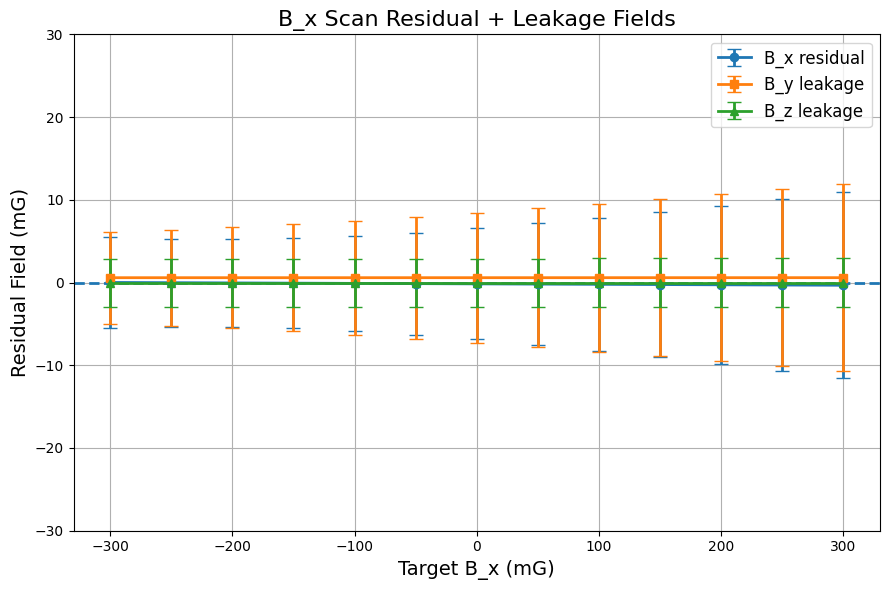

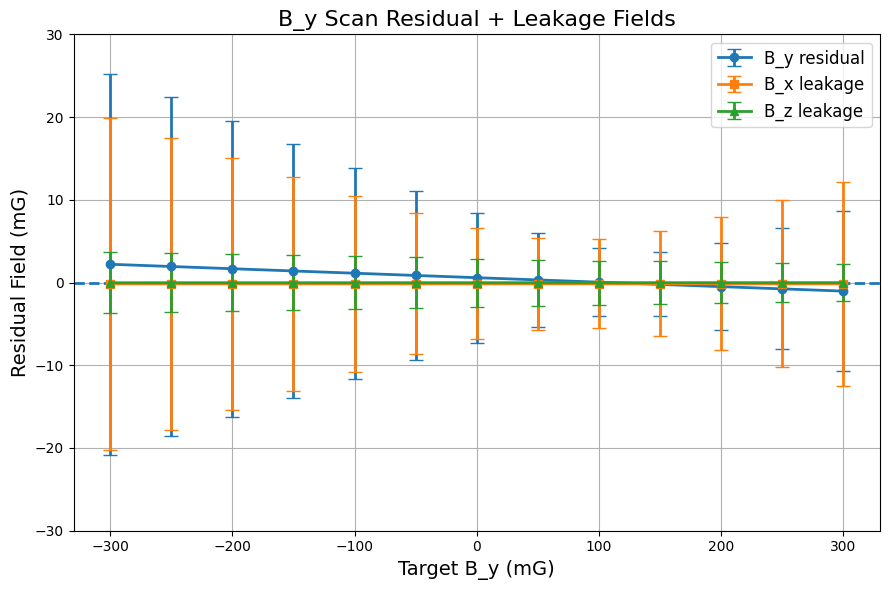

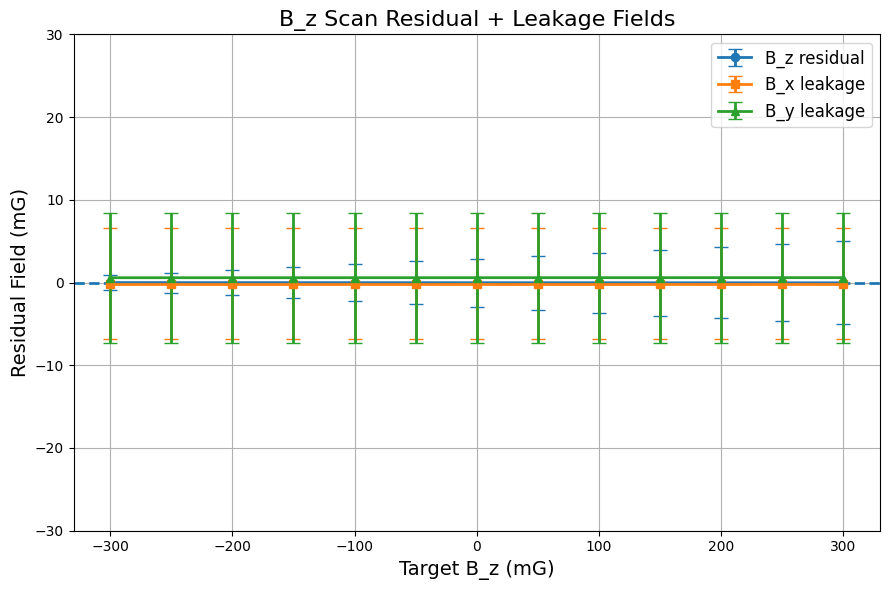

In [46]:
# ============================================================
# RESIDUAL + LEAKAGE PLOTS
#
# FOR EACH SCAN:
#
# Plot:
#
# (B_actual - B_target)
#
# for ALL THREE COMPONENTS
#
# Example:
#
# Bx scan:
#   Bx residual
#   By leakage
#   Bz leakage
#
# all in SAME graph
#
# ============================================================

import matplotlib.pyplot as plt

# ============================================================
# GENERIC MULTI-COMPONENT RESIDUAL PLOT
# ============================================================

def plot_full_residual_scan(

    scan_values,

    main_mean,
    main_rms,

    leak1_mean,
    leak1_rms,

    leak2_mean,
    leak2_rms,

    scan_name,

    leak1_name,
    leak2_name
):

    # --------------------------------------------------------
    # MAIN RESIDUAL
    # --------------------------------------------------------

    main_residual = main_mean - scan_values

    # --------------------------------------------------------
    # LEAKAGE RESIDUALS
    #
    # leakage target = 0
    # --------------------------------------------------------

    leak1_residual = leak1_mean

    leak2_residual = leak2_mean

    # --------------------------------------------------------
    # PLOT
    # --------------------------------------------------------

    plt.figure(figsize=(9,6))

    # --------------------------------------------------------
    # MAIN COMPONENT
    # --------------------------------------------------------

    plt.errorbar(

        scan_values,

        main_residual,

        yerr=main_rms,

        fmt='o-',

        capsize=5,

        linewidth=2,

        label=f'{scan_name} residual'
    )

    # --------------------------------------------------------
    # LEAKAGE 1
    # --------------------------------------------------------

    plt.errorbar(

        scan_values,

        leak1_residual,

        yerr=leak1_rms,

        fmt='s-',

        capsize=5,

        linewidth=2,

        label=f'{leak1_name} leakage'
    )

    # --------------------------------------------------------
    # LEAKAGE 2
    # --------------------------------------------------------

    plt.errorbar(

        scan_values,

        leak2_residual,

        yerr=leak2_rms,

        fmt='^-',

        capsize=5,

        linewidth=2,

        label=f'{leak2_name} leakage'
    )

    # --------------------------------------------------------
    # ZERO LINE
    # --------------------------------------------------------

    plt.axhline(

        y=0,

        linestyle='--',

        linewidth=2
    )

    # --------------------------------------------------------
    # LABELS
    # --------------------------------------------------------

    plt.xlabel(

        rf'Target {scan_name} (mG)',

        fontsize=14
    )

    plt.ylabel(

        'Residual Field (mG)',

        fontsize=14
    )

    plt.title(

        rf'{scan_name} Scan Residual + Leakage Fields',

        fontsize=16
    )

    # --------------------------------------------------------
    # FIXED RANGE
    # --------------------------------------------------------

    plt.ylim(-30, 30)

    plt.grid(True)

    plt.legend(fontsize=12)

    plt.tight_layout()

    plt.show()

# ============================================================
# Bx SCAN
#
# show:
# Bx residual
# By leakage
# Bz leakage
# ============================================================

plot_full_residual_scan(

    scan_values,

    results_Bx['Bx_mean'],
    results_Bx['Bx_rms'],

    results_Bx['By_mean'],
    results_Bx['By_rms'],

    results_Bx['Bz_mean'],
    results_Bx['Bz_rms'],

    scan_name='B_x',

    leak1_name='B_y',
    leak2_name='B_z'
)

# ============================================================
# By SCAN
#
# show:
# By residual
# Bx leakage
# Bz leakage
# ============================================================

plot_full_residual_scan(

    scan_values,

    results_By['By_mean'],
    results_By['By_rms'],

    results_By['Bx_mean'],
    results_By['Bx_rms'],

    results_By['Bz_mean'],
    results_By['Bz_rms'],

    scan_name='B_y',

    leak1_name='B_x',
    leak2_name='B_z'
)

# ============================================================
# Bz SCAN
#
# show:
# Bz residual
# Bx leakage
# By leakage
# ============================================================

plot_full_residual_scan(

    scan_values,

    results_Bz['Bz_mean'],
    results_Bz['Bz_rms'],

    results_Bz['Bx_mean'],
    results_Bz['Bx_rms'],

    results_Bz['By_mean'],
    results_Bz['By_rms'],

    scan_name='B_z',

    leak1_name='B_x',
    leak2_name='B_y'
)

A shape = (18, 7)
A_red shape = (18, 4)

Bx TARGET = -300 mG

Optimized currents:
X13 = -3.615 A
X2  = -2.076 A
Y   = -23.590 A
Z   = 71.825 A

Actual fields at 6 PMTs:

Bx:
[-295.564 -304.518 -291.499 -301.467 -298.752 -308.147]

By:
[-2.897 -3.209  8.779 -3.461 -3.81   8.1  ]

Bz:
[ 3.777 -1.937  1.205  0.985 -5.373  1.221]

Bx TARGET = -250 mG

Optimized currents:
X13 = 7.394 A
X2  = 4.070 A
Y   = -23.512 A
Z   = 71.829 A

Actual fields at 6 PMTs:

Bx:
[-246.562 -253.076 -242.126 -252.06  -247.574 -258.718]

By:
[-3.71  -2.94   8.223 -3.976 -3.401  9.308]

Bz:
[ 3.765 -1.953  1.243  0.982 -5.375  1.217]

Bx TARGET = -200 mG

Optimized currents:
X13 = 18.404 A
X2  = 10.217 A
Y   = -23.434 A
Z   = 71.832 A

Actual fields at 6 PMTs:

Bx:
[-197.56  -201.635 -192.752 -202.653 -196.396 -209.29 ]

By:
[-4.524 -2.67   7.667 -4.492 -2.992 10.515]

Bz:
[ 3.753 -1.968  1.28   0.978 -5.376  1.212]

Bx TARGET = -150 mG

Optimized currents:
X13 = 29.413 A
X2  = 16.363 A
Y   = -23.356 A
Z   = 71.8

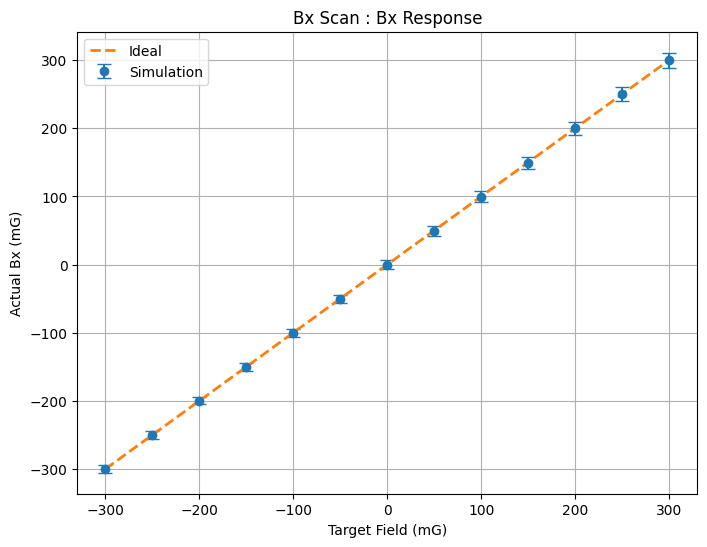

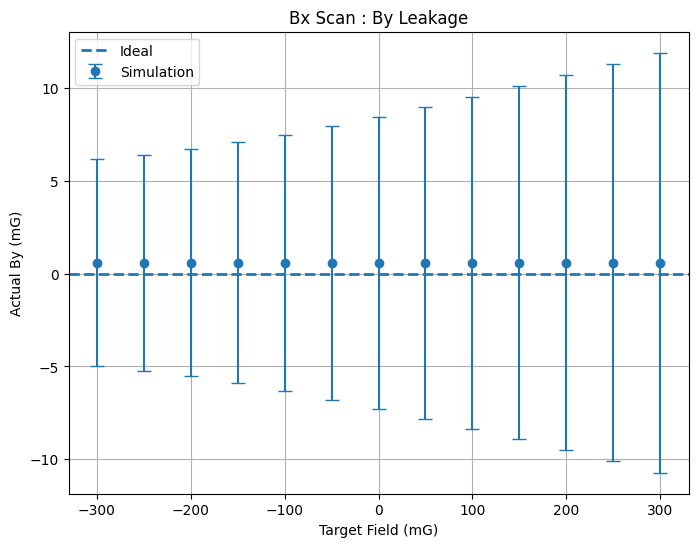

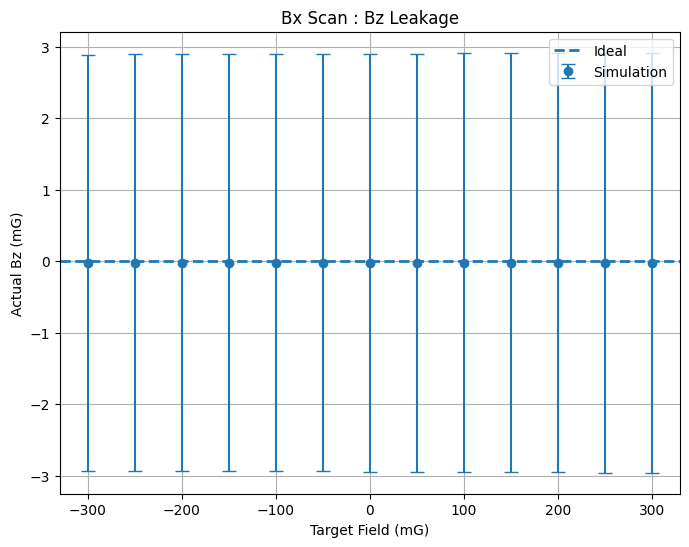

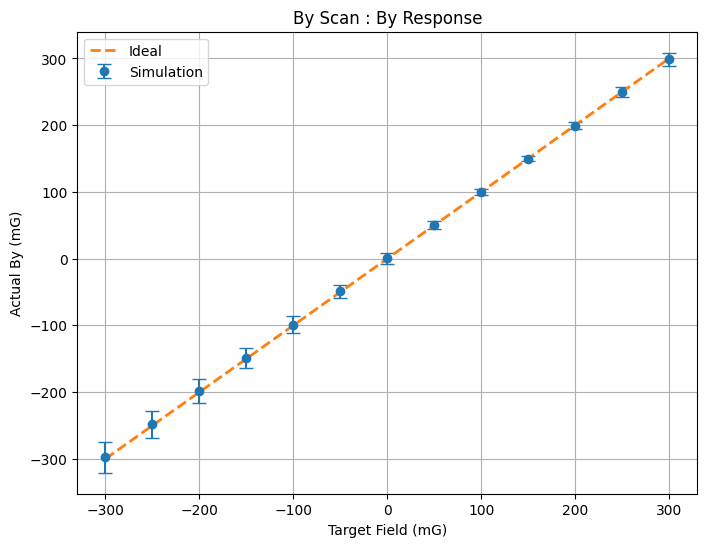

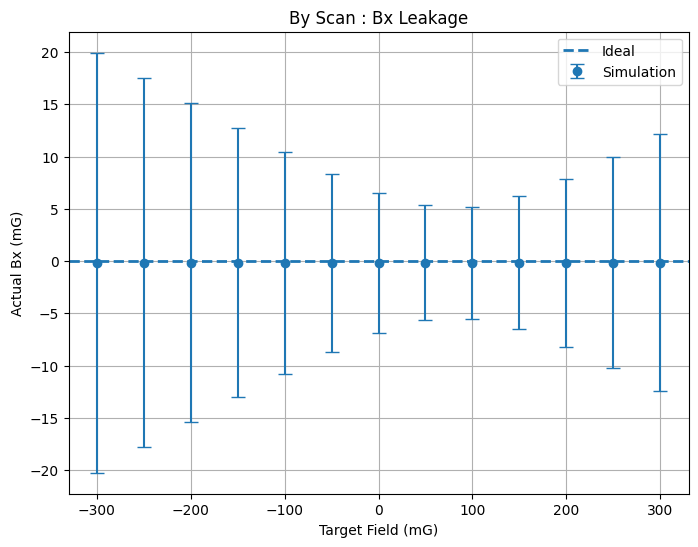

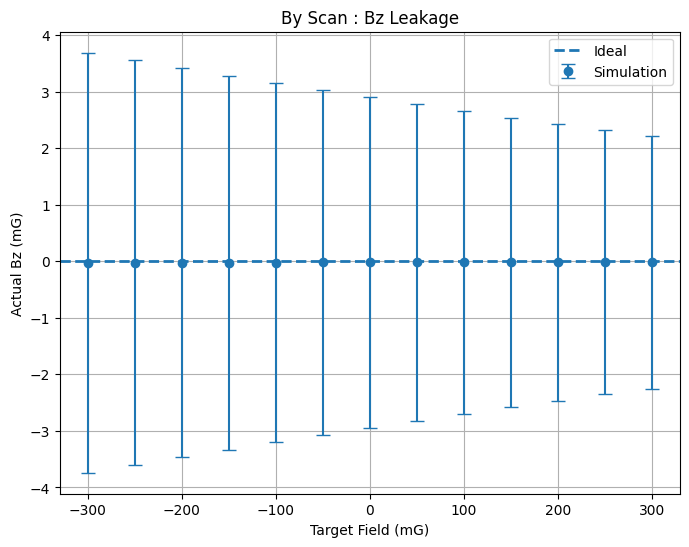

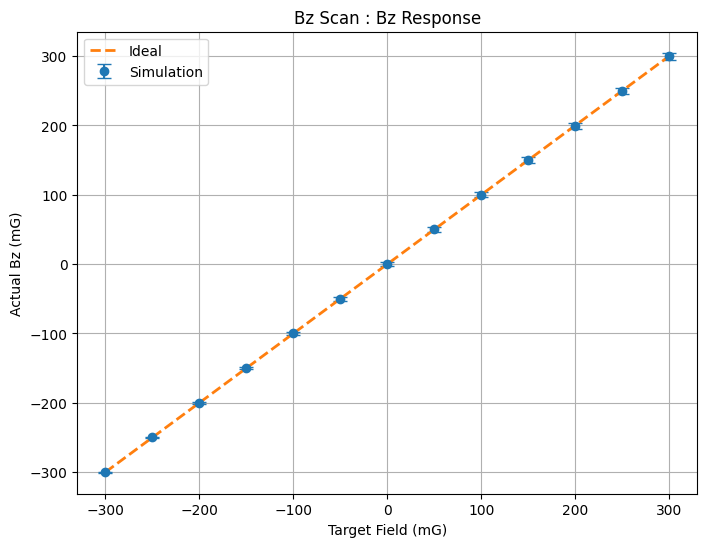

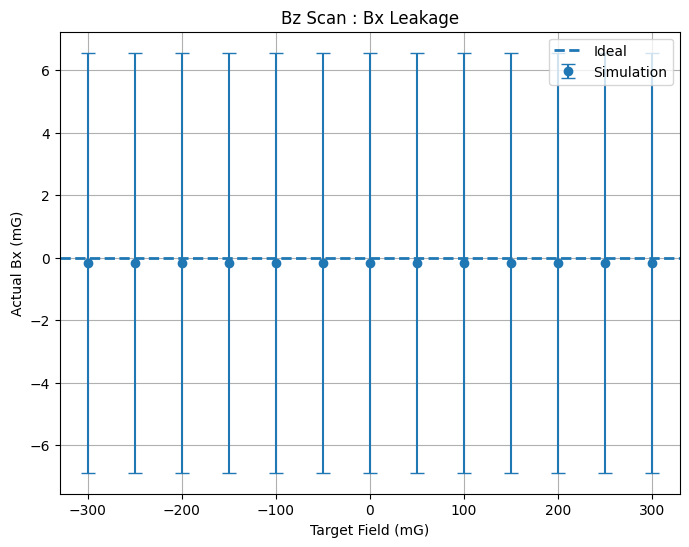

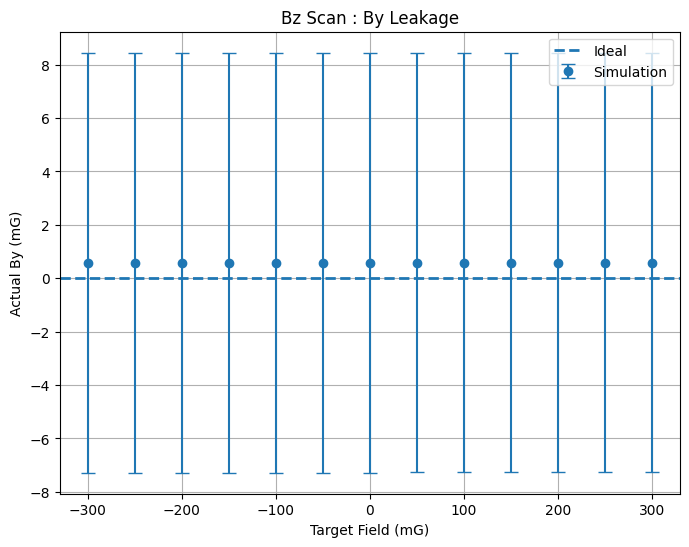

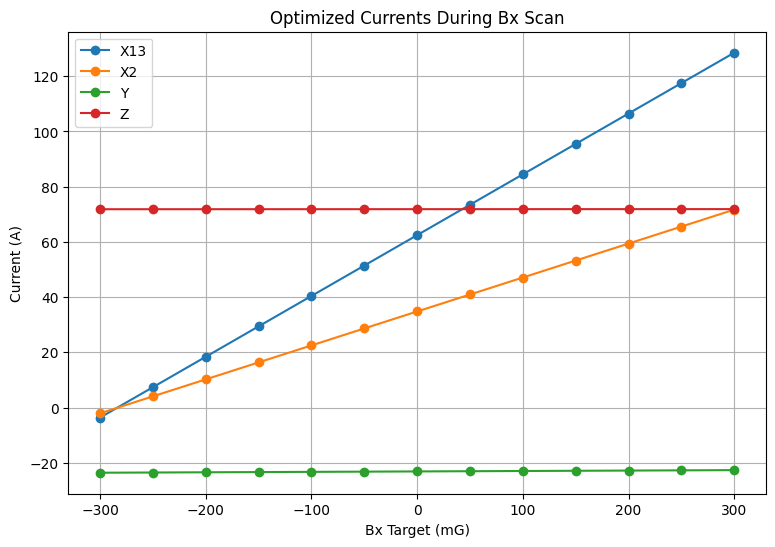

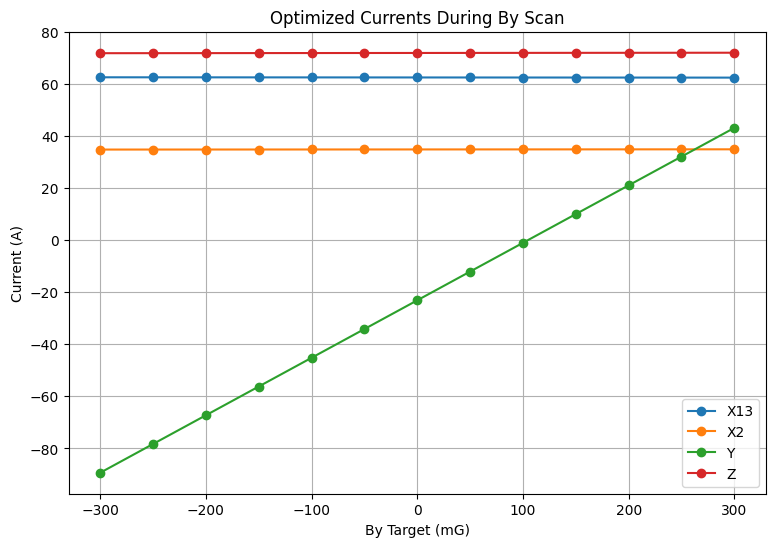

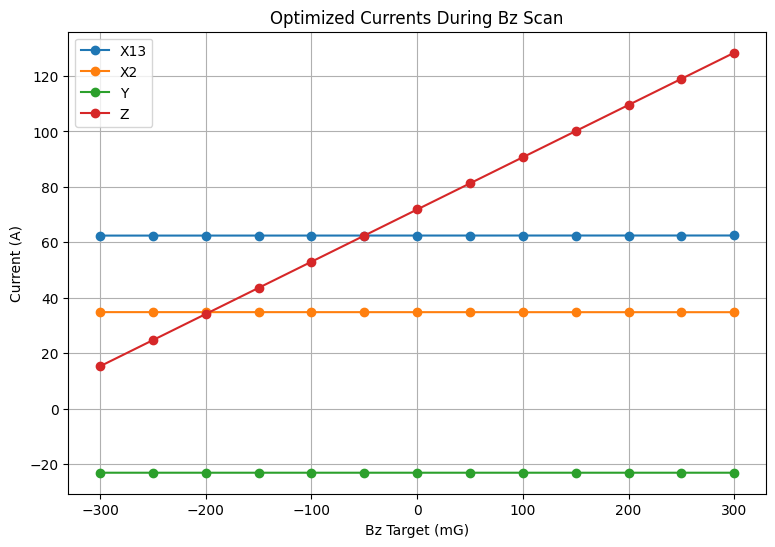

In [44]:
# ============================================================
# GLOBAL PMT SCAN ANALYSIS
#
# 6 PMT CENTERS
#
# GROUPING:
#   X1 = X3
#   X2 independent
#   Y1 = Y2
#   Z1 = Z2
#
# UNKNOWNS:
#
#   [X13, X2, Y, Z]
#
# ============================================================

import numpy as np
import matplotlib.pyplot as plt

from pathlib import Path

# ============================================================
# LOAD MATRIX
# ============================================================

project_root = Path.cwd().parent

data_dir = project_root / "data"

A = np.load(data_dir / "A.npy")

print("A shape =", A.shape)

# ============================================================
# REDUCED MATRIX
#
# X1 + X3 grouped
# X2 independent
# Y grouped
# Z grouped
# ============================================================

A_red = np.column_stack([

    A[:,0] + A[:,2],     # X13 grouped

    A[:,1],              # X2 independent

    A[:,3] + A[:,4],     # Y grouped

    A[:,5] + A[:,6]      # Z grouped
])

print("A_red shape =", A_red.shape)

# ============================================================
# AMBIENT FIELD
# ============================================================

B_ambient = np.array([

    -283.38,
     106.79,
    -381.21
])

# ============================================================
# SCAN VALUES
# ============================================================

scan_values = np.arange(

    -300,
     301,
      50
)

# ============================================================
# FUNCTION:
# RUN SCAN
# ============================================================

def run_scan(scan_component='Bx'):

    # --------------------------------------------------------
    # STORAGE
    # --------------------------------------------------------

    actual_means_x = []
    actual_rms_x   = []

    actual_means_y = []
    actual_rms_y   = []

    actual_means_z = []
    actual_rms_z   = []

    currents_all = []

    # --------------------------------------------------------
    # LOOP OVER TARGETS
    # --------------------------------------------------------

    for target in scan_values:

        # ----------------------------------------------------
        # USER TARGET FIELD
        # ----------------------------------------------------

        if scan_component == 'Bx':

            B_in = np.array([

                target,
                0,
                0
            ])

        elif scan_component == 'By':

            B_in = np.array([

                0,
                target,
                0
            ])

        elif scan_component == 'Bz':

            B_in = np.array([

                0,
                0,
                target
            ])

        # ----------------------------------------------------
        # FIELD REQUIRED FROM COILS
        # ----------------------------------------------------

        target_single = B_in - B_ambient

        # ----------------------------------------------------
        # BUILD 18-DIM TARGET VECTOR
        # ----------------------------------------------------

        Bx_vec = np.full(

            6,
            target_single[0]
        )

        By_vec = np.full(

            6,
            target_single[1]
        )

        Bz_vec = np.full(

            6,
            target_single[2]
        )

        B_target = np.concatenate([

            Bx_vec,
            By_vec,
            Bz_vec
        ])

        # ----------------------------------------------------
        # LEAST-SQUARES OPTIMIZATION
        # ----------------------------------------------------

        I_opt, residuals, rank, s = np.linalg.lstsq(

            A_red,
            B_target,
            rcond=None
        )

        currents_all.append(I_opt)

        # ----------------------------------------------------
        # COIL FIELD
        # ----------------------------------------------------

        B_coil = A_red @ I_opt

        # ----------------------------------------------------
        # BUILD AMBIENT VECTOR
        # ----------------------------------------------------

        B_ambient_vec = np.concatenate([

            np.full(6, B_ambient[0]),

            np.full(6, B_ambient[1]),

            np.full(6, B_ambient[2])
        ])

        # ----------------------------------------------------
        # TOTAL FIELD
        # ----------------------------------------------------

        B_actual = B_coil + B_ambient_vec

        # ----------------------------------------------------
        # EXTRACT COMPONENTS
        # ----------------------------------------------------

        Bx_actual = B_actual[:6]

        By_actual = B_actual[6:12]

        Bz_actual = B_actual[12:18]

        # ----------------------------------------------------
        # STORE STATISTICS
        # ----------------------------------------------------

        actual_means_x.append(

            np.mean(Bx_actual)
        )

        actual_rms_x.append(

            np.std(Bx_actual)
        )

        actual_means_y.append(

            np.mean(By_actual)
        )

        actual_rms_y.append(

            np.std(By_actual)
        )

        actual_means_z.append(

            np.mean(Bz_actual)
        )

        actual_rms_z.append(

            np.std(Bz_actual)
        )

        # ----------------------------------------------------
        # PRINT RESULTS
        # ----------------------------------------------------

        print("\n================================================")

        print(f"{scan_component} TARGET = {target} mG")

        print("================================================")

        print("\nOptimized currents:")

        print(f"X13 = {I_opt[0]:.3f} A")

        print(f"X2  = {I_opt[1]:.3f} A")

        print(f"Y   = {I_opt[2]:.3f} A")

        print(f"Z   = {I_opt[3]:.3f} A")

        print("\nActual fields at 6 PMTs:")

        print("\nBx:")
        print(np.round(Bx_actual,3))

        print("\nBy:")
        print(np.round(By_actual,3))

        print("\nBz:")
        print(np.round(Bz_actual,3))

    # --------------------------------------------------------
    # RETURN
    # --------------------------------------------------------

    return {

        'currents': np.array(currents_all),

        'Bx_mean': np.array(actual_means_x),
        'Bx_rms':  np.array(actual_rms_x),

        'By_mean': np.array(actual_means_y),
        'By_rms':  np.array(actual_rms_y),

        'Bz_mean': np.array(actual_means_z),
        'Bz_rms':  np.array(actual_rms_z),
    }

# ============================================================
# RUN SCANS
# ============================================================

results_Bx = run_scan('Bx')

results_By = run_scan('By')

results_Bz = run_scan('Bz')

# ============================================================
# FUNCTION:
# PLOT RESPONSE
# ============================================================

def plot_response(

    targets,
    means,
    rms,

    ylabel,
    title,

    ideal='diagonal'
):

    plt.figure(figsize=(8,6))

    # --------------------------------------------------------
    # ERROR BARS
    # --------------------------------------------------------

    plt.errorbar(

        targets,
        means,

        yerr=rms,

        fmt='o',

        capsize=5,

        label='Simulation'
    )

    # --------------------------------------------------------
    # IDEAL LINE
    # --------------------------------------------------------

    if ideal == 'diagonal':

        plt.plot(

            targets,
            targets,

            '--',

            linewidth=2,

            label='Ideal'
        )

    elif ideal == 'zero':

        plt.axhline(

            y=0,

            linestyle='--',

            linewidth=2,

            label='Ideal'
        )

    # --------------------------------------------------------
    # LABELS
    # --------------------------------------------------------

    plt.xlabel('Target Field (mG)')

    plt.ylabel(ylabel)

    plt.title(title)

    plt.grid(True)

    plt.legend()

    plt.show()

# ============================================================
# Bx SCAN
# ============================================================

plot_response(

    scan_values,

    results_Bx['Bx_mean'],
    results_Bx['Bx_rms'],

    'Actual Bx (mG)',

    'Bx Scan : Bx Response',

    ideal='diagonal'
)

plot_response(

    scan_values,

    results_Bx['By_mean'],
    results_Bx['By_rms'],

    'Actual By (mG)',

    'Bx Scan : By Leakage',

    ideal='zero'
)

plot_response(

    scan_values,

    results_Bx['Bz_mean'],
    results_Bx['Bz_rms'],

    'Actual Bz (mG)',

    'Bx Scan : Bz Leakage',

    ideal='zero'
)

# ============================================================
# By SCAN
# ============================================================

plot_response(

    scan_values,

    results_By['By_mean'],
    results_By['By_rms'],

    'Actual By (mG)',

    'By Scan : By Response',

    ideal='diagonal'
)

plot_response(

    scan_values,

    results_By['Bx_mean'],
    results_By['Bx_rms'],

    'Actual Bx (mG)',

    'By Scan : Bx Leakage',

    ideal='zero'
)

plot_response(

    scan_values,

    results_By['Bz_mean'],
    results_By['Bz_rms'],

    'Actual Bz (mG)',

    'By Scan : Bz Leakage',

    ideal='zero'
)

# ============================================================
# Bz SCAN
# ============================================================

plot_response(

    scan_values,

    results_Bz['Bz_mean'],
    results_Bz['Bz_rms'],

    'Actual Bz (mG)',

    'Bz Scan : Bz Response',

    ideal='diagonal'
)

plot_response(

    scan_values,

    results_Bz['Bx_mean'],
    results_Bz['Bx_rms'],

    'Actual Bx (mG)',

    'Bz Scan : Bx Leakage',

    ideal='zero'
)

plot_response(

    scan_values,

    results_Bz['By_mean'],
    results_Bz['By_rms'],

    'Actual By (mG)',

    'Bz Scan : By Leakage',

    ideal='zero'
)

# ============================================================
# CURRENT EVOLUTION PLOTS
# ============================================================

coil_labels = [

    'X13',
    'X2',
    'Y',
    'Z'
]

# ------------------------------------------------------------
# Bx scan currents
# ------------------------------------------------------------

plt.figure(figsize=(9,6))

for i in range(4):

    plt.plot(

        scan_values,

        results_Bx['currents'][:,i],

        marker='o',

        label=coil_labels[i]
    )

plt.xlabel('Bx Target (mG)')

plt.ylabel('Current (A)')

plt.title('Optimized Currents During Bx Scan')

plt.grid(True)

plt.legend()

plt.show()

# ------------------------------------------------------------
# By scan currents
# ------------------------------------------------------------

plt.figure(figsize=(9,6))

for i in range(4):

    plt.plot(

        scan_values,

        results_By['currents'][:,i],

        marker='o',

        label=coil_labels[i]
    )

plt.xlabel('By Target (mG)')

plt.ylabel('Current (A)')

plt.title('Optimized Currents During By Scan')

plt.grid(True)

plt.legend()

plt.show()

# ------------------------------------------------------------
# Bz scan currents
# ------------------------------------------------------------

plt.figure(figsize=(9,6))

for i in range(4):

    plt.plot(

        scan_values,

        results_Bz['currents'][:,i],

        marker='o',

        label=coil_labels[i]
    )

plt.xlabel('Bz Target (mG)')

plt.ylabel('Current (A)')

plt.title('Optimized Currents During Bz Scan')

plt.grid(True)

plt.legend()

plt.show()